# Week 3: Feature Selection, PCR, and PLSR

Same marketing/product performance dataset as the original Week 3 notebook. I am keeping the forward selection work and adding the missing methods for the milestone.

## Forward Selection

This keeps the original forward selection idea: start small, add useful variables, and test the selected set on ROI.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/riverocel/Downloads/marketing_and_product_performance.csv")
df.head()
df.info()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  object 
 1   Product_ID                         10000 non-null  object 
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-null  float64
 6   ROI                                10000 non-null  float64
 7   Customer_ID                        10000 non-null  object 
 8   Subscription_Tier                  10000 non-null  object 
 9   Subscription_Length                10000 non-null  int64  
 10  Flash_Sale_ID                      10000 non-null  object 
 11  Discount_Level                     10000 non-null  int6

In [2]:
target = "ROI"

X = df.drop(columns=[
    target,
    "Campaign_ID",
    "Product_ID",
    "Customer_ID",
    "Flash_Sale_ID",
    "Bundle_ID"
])

y = df[target]
categorical = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical variables:")
print(categorical)

print("\nNumeric variables:")
print(numeric)

Categorical variables:
['Subscription_Tier', 'Common_Keywords']

Numeric variables:
['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print(X_train_df.shape)
X_train_df.head()

(8000, 14)


,num__Budget,num__Clicks,num__Conversions,num__Revenue_Generated,num__Subscription_Length,num__Discount_Level,num__Units_Sold,num__Bundle_Price,num__Customer_Satisfaction_Post_Refund,cat__Subscription_Tier_Premium,cat__Subscription_Tier_Standard,cat__Common_Keywords_Durable,cat__Common_Keywords_Innovative,cat__Common_Keywords_Stylish
0,-1.264876,0.170499,-0.436694,0.826389,0.089523,1.661845,0.182056,-0.220254,-0.442737,1.0,0.0,0.0,1.0,0.0
1,-0.534454,-1.731882,-0.405557,-1.277233,-0.502607,0.209405,-1.595821,-0.942892,0.454854,0.0,0.0,0.0,0.0,1.0
2,-1.470049,-1.239320,-0.710006,0.214018,-0.798672,-0.371570,0.286637,-0.203269,-1.340327,0.0,0.0,0.0,1.0,0.0
3,0.953819,1.070264,1.390003,1.251505,1.372470,-0.429668,-1.282078,0.456061,-0.442737,0.0,0.0,0.0,1.0,0.0
4,0.507874,-1.236522,-1.702927,1.392786,-1.094737,1.603748,-1.264648,1.022591,0.454854,0.0,0.0,0.0,0.0,1.0


# forward selection to pick the best features 

In [4]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

# LR
lr = LinearRegression()

#FS
forward = SequentialFeatureSelector(
    lr,
    n_features_to_select="auto",
    direction="forward",
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

forward.fit(X_train_df, y_train)

selected_features = X_train_df.columns[forward.get_support()]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['num__Budget', 'num__Clicks', 'num__Revenue_Generated', 'num__Discount_Level', 'num__Bundle_Price', 'cat__Subscription_Tier_Standard', 'cat__Common_Keywords_Innovative']


best features selected, getting r2 next

In [5]:
forward_model = LinearRegression()

forward_model.fit(
    X_train_df[selected_features],
    y_train
)

pred = forward_model.predict(
    X_test_df[selected_features]
)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

RMSE: 1.302
R²: -0.001


the model actually performed horrible, because of the synthetic data the variables have a really bad connection with ROI, there are essentially not a single strong one.

## Backward Selection

Backward selection starts with the full processed feature set and removes features that are not helping much. It is the opposite direction from forward selection, but the goal is still a smaller model.

In [6]:
backward = SequentialFeatureSelector(
    lr,
    n_features_to_select="auto",
    direction="backward",
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

backward.fit(X_train_df, y_train)

backward_features = X_train_df.columns[backward.get_support()]

backward_model = LinearRegression()
backward_model.fit(X_train_df[backward_features], y_train)
backward_pred = backward_model.predict(X_test_df[backward_features])

print("Selected Features:")
print(backward_features.tolist())

Selected Features:
['num__Budget', 'num__Clicks', 'num__Revenue_Generated', 'num__Discount_Level', 'num__Bundle_Price', 'cat__Subscription_Tier_Standard', 'cat__Common_Keywords_Innovative']


## PCR and PLSR

PCR turns the predictors into principal components first, then uses those components in regression. PLSR is similar, but it builds components while also paying attention to the target variable.

In [7]:
n_pcr_components = min(10, X_train_df.shape[1])

pcr_model = Pipeline([
    ("pca", PCA(n_components=n_pcr_components, random_state=42)),
    ("model", LinearRegression())
])

pcr_model.fit(X_train_df, y_train)
pcr_pred = pcr_model.predict(X_test_df)

n_pls_components = min(5, X_train_df.shape[1])

pls_model = PLSRegression(n_components=n_pls_components)
pls_model.fit(X_train_df, y_train)
pls_pred = pls_model.predict(X_test_df).ravel()

## Week 3 Model Comparison

This table puts the Week 3 models next to each other. ROI is pretty hard to predict here, which matters because weak ROI models are not very reliable for budget decisions.

In [8]:
def regression_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

week3_results = pd.DataFrame([
    regression_metrics("Forward Selection", y_test, pred),
    regression_metrics("Backward Selection", y_test, backward_pred),
    regression_metrics("PCR", y_test, pcr_pred),
    regression_metrics("PLSR", y_test, pls_pred),
]).sort_values("R2", ascending=False)

week3_results.round(4)

,Model,RMSE,MAE,R2
2,PCR,1.3014,1.1228,-0.0002
0,Forward Selection,1.3016,1.1230,-0.0006
1,Backward Selection,1.3016,1.1230,-0.0006
3,PLSR,1.3018,1.1233,-0.0009


## Week 3 Visuals

Since the Week 3 models are all close, these charts make it easier to see that none of them predicted ROI very well.

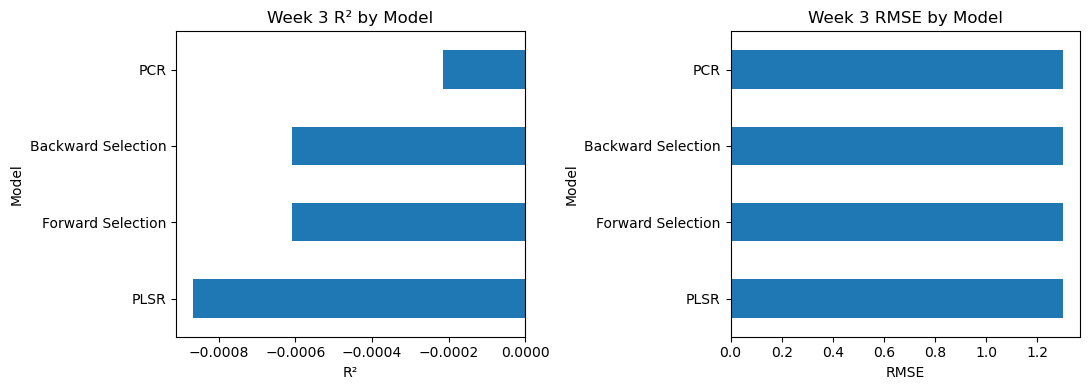

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

week3_results.sort_values("R2").plot(
    x="Model",
    y="R2",
    kind="barh",
    ax=axes[0],
    legend=False
)
axes[0].set_title("Week 3 R² by Model")
axes[0].set_xlabel("R²")

week3_results.sort_values("RMSE", ascending=False).plot(
    x="Model",
    y="RMSE",
    kind="barh",
    ax=axes[1],
    legend=False
)
axes[1].set_title("Week 3 RMSE by Model")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

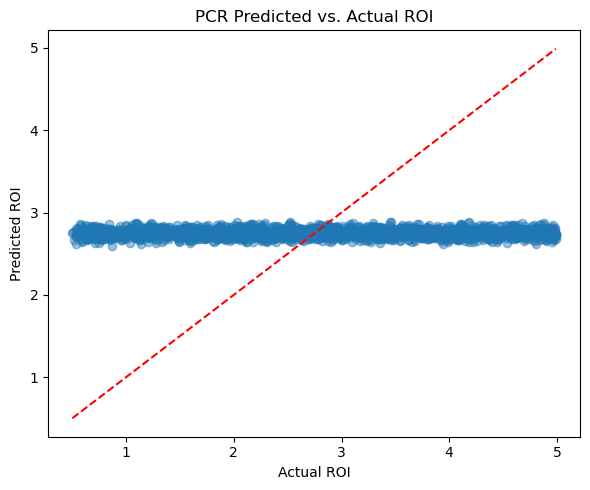

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pcr_pred, alpha=0.45)

line_min = min(y_test.min(), pcr_pred.min())
line_max = max(y_test.max(), pcr_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--")

plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.title("PCR Predicted vs. Actual ROI")
plt.tight_layout()
plt.show()